# PresentAI Coach — Model Evaluation & Submission Results

This notebook generates the final evaluation evidence for the posture classifier used in **PresentAI Coach**.

It loads the saved evaluation model and reconstructs the same unseen group-aware holdout set used during training.

It produces:
- Dataset class distribution
- Dataset source distribution
- Confusion matrix
- ROC curve
- Final evaluation metrics
- Classification report

> This notebook does **not retrain** the model.


In [3]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    classification_report,
)

MODEL_PATH = "models/posture_classifier_eval.pkl"
ROBOFLOW_CSV = "data/processed/roboflow_posture_features.csv"
REAL_CSV = "data/processed/real_video_features.csv"
SYNTHETIC_CSV = "data/processed/synthetic_good_bad_features.csv"

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)


## 1. Helper Functions

In [4]:
def load_csv(path, source_name):
    if not os.path.exists(path):
        print(f"WARNING: Missing file: {path}")
        return pd.DataFrame()

    df = pd.read_csv(path)
    df["data_source"] = source_name
    return df


def create_group_id(row):
    source_file = str(row.get("source_file", "unknown"))

    if row["data_source"] in {"real_video", "synthetic_video"}:
        return f"{row['data_source']}::{source_file}"

    source_dataset = str(row.get("source_dataset", "unknown_dataset"))
    return f"roboflow::{source_dataset}::{source_file}"


def prepare_features(df, feature_names):
    X = df.copy()

    for feature in feature_names:
        if feature not in X.columns:
            X[feature] = np.nan

    X = X[feature_names]

    for column in X.columns:
        X[column] = pd.to_numeric(X[column], errors="coerce")

    return X


## 2. Load Evaluation Model

In [5]:
package = joblib.load(MODEL_PATH)

model = package["model"]
feature_names = package["features"]
holdout_groups = set(package["holdout_groups"])

print("Model:", package.get("model_name", "Unknown"))
print("Number of features:", len(feature_names))
print("Saved holdout groups:", len(holdout_groups))


Model: Random Forest
Number of features: 19
Saved holdout groups: 64


## 3. Load and Reconstruct Dataset

In [6]:
roboflow_df = load_csv(ROBOFLOW_CSV, "roboflow")
real_df = load_csv(REAL_CSV, "real_video")
synthetic_df = load_csv(SYNTHETIC_CSV, "synthetic_video")

data = pd.concat(
    [roboflow_df, real_df, synthetic_df],
    ignore_index=True,
    sort=False,
)

data["label"] = (
    data["label"]
    .astype(str)
    .str.lower()
    .str.strip()
)

data = data[
    data["label"].isin(["good", "bad"])
].copy()

data["group_id"] = data.apply(
    create_group_id,
    axis=1,
)

holdout_df = data[
    data["group_id"].isin(holdout_groups)
].copy()

print("Total dataset rows:", len(data))
print("Unique groups:", data["group_id"].nunique())
print("Holdout rows:", len(holdout_df))
print("Holdout groups:", holdout_df["group_id"].nunique())


Total dataset rows: 998
Unique groups: 324
Holdout rows: 296
Holdout groups: 64


## 4. Dataset Class Distribution

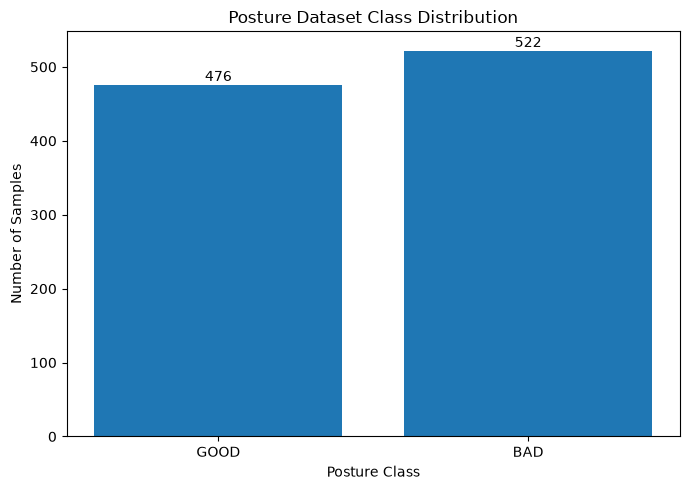

label
good    476
bad     522
Name: count, dtype: int64

In [7]:
class_counts = (
    data["label"]
    .value_counts()
    .reindex(["good", "bad"], fill_value=0)
)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ["GOOD", "BAD"],
    class_counts.values,
)

ax.set_title("Posture Dataset Class Distribution")
ax.set_xlabel("Posture Class")
ax.set_ylabel("Number of Samples")

for bar, value in zip(bars, class_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(value),
        ha="center",
    )

plt.tight_layout()

plt.savefig(
    os.path.join(RESULTS_DIR, "01_class_distribution.png"),
    dpi=220,
    bbox_inches="tight",
)

plt.show()

class_counts


## 5. Dataset Source Distribution

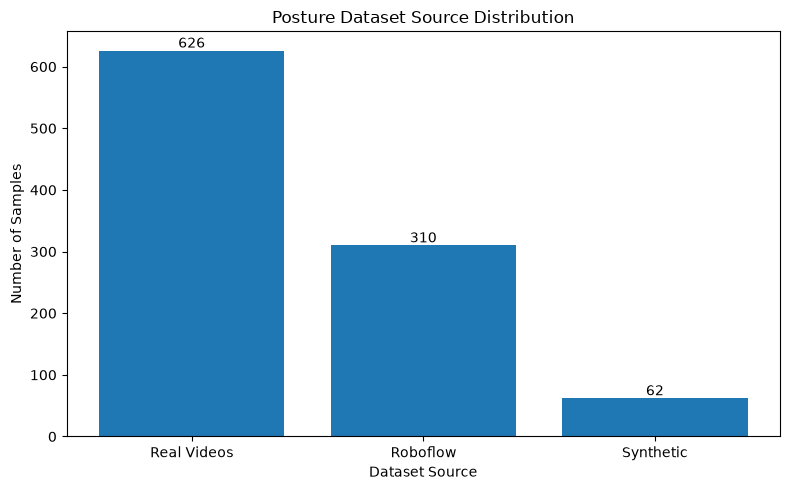

data_source
real_video         626
roboflow           310
synthetic_video     62
Name: count, dtype: int64

In [8]:
source_counts = data["data_source"].value_counts()

readable_names = {
    "real_video": "Real Videos",
    "roboflow": "Roboflow",
    "synthetic_video": "Synthetic",
}

labels = [
    readable_names.get(source, source)
    for source in source_counts.index
]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    labels,
    source_counts.values,
)

ax.set_title("Posture Dataset Source Distribution")
ax.set_xlabel("Dataset Source")
ax.set_ylabel("Number of Samples")

for bar, value in zip(bars, source_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(value),
        ha="center",
    )

plt.tight_layout()

plt.savefig(
    os.path.join(RESULTS_DIR, "02_dataset_source_distribution.png"),
    dpi=220,
    bbox_inches="tight",
)

plt.show()

source_counts


## 6. Evaluate the Unseen Holdout Set

In [9]:
X_holdout = prepare_features(
    holdout_df,
    feature_names,
)

y_holdout = (
    holdout_df["label"]
    .astype(str)
    .str.lower()
    .str.strip()
)

predictions = model.predict(X_holdout)

accuracy = accuracy_score(y_holdout, predictions)

precision = precision_score(
    y_holdout,
    predictions,
    pos_label="good",
    zero_division=0,
)

recall = recall_score(
    y_holdout,
    predictions,
    pos_label="good",
    zero_division=0,
)

macro_f1 = f1_score(
    y_holdout,
    predictions,
    average="macro",
    zero_division=0,
)

probabilities = model.predict_proba(X_holdout)

classes = list(model.classes_)
good_index = classes.index("good")
good_probabilities = probabilities[:, good_index]

binary_truth = (
    y_holdout == "good"
).astype(int)

roc_auc = roc_auc_score(
    binary_truth,
    good_probabilities,
)

metrics_df = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision (GOOD)",
            "Recall (GOOD)",
            "Macro F1",
            "ROC-AUC",
        ],
        "Score": [
            accuracy,
            precision,
            recall,
            macro_f1,
            roc_auc,
        ],
    }
)

metrics_df


,Metric,Score
0,Accuracy,0.746622
1,Precision (GOOD),0.720588
2,Recall (GOOD),0.725926
3,Macro F1,0.744801
4,ROC-AUC,0.806579


## 7. Confusion Matrix

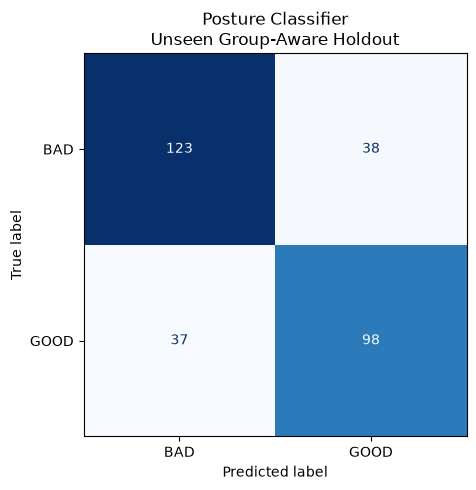

In [10]:
matrix = confusion_matrix(
    y_holdout,
    predictions,
    labels=["bad", "good"],
)

display = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=["BAD", "GOOD"],
)

fig, ax = plt.subplots(figsize=(6, 5))

display.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
)

ax.set_title(
    "Posture Classifier\n"
    "Unseen Group-Aware Holdout"
)

plt.tight_layout()

plt.savefig(
    os.path.join(RESULTS_DIR, "03_confusion_matrix.png"),
    dpi=220,
    bbox_inches="tight",
)

plt.show()


## 8. ROC Curve

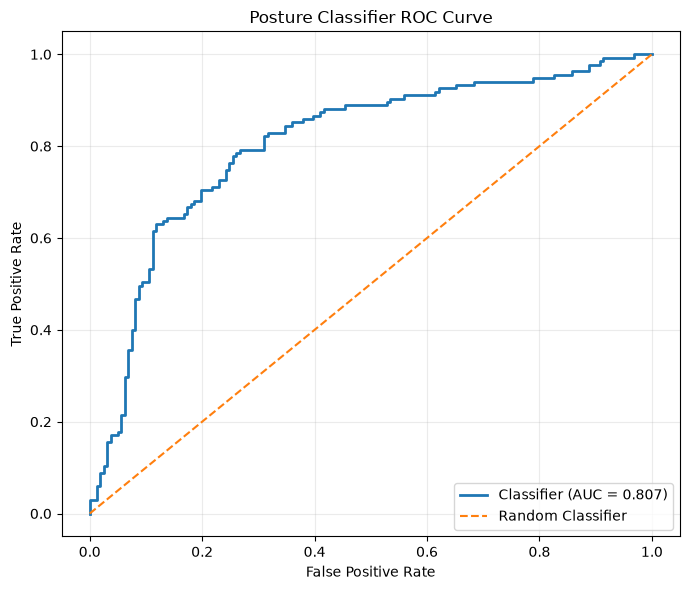

In [11]:
fpr, tpr, _ = roc_curve(
    binary_truth,
    good_probabilities,
)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Classifier (AUC = {roc_auc:.3f})",
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier",
)

ax.set_title("Posture Classifier ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    os.path.join(RESULTS_DIR, "04_roc_curve.png"),
    dpi=220,
    bbox_inches="tight",
)

plt.show()


## 9. Final Performance Metrics

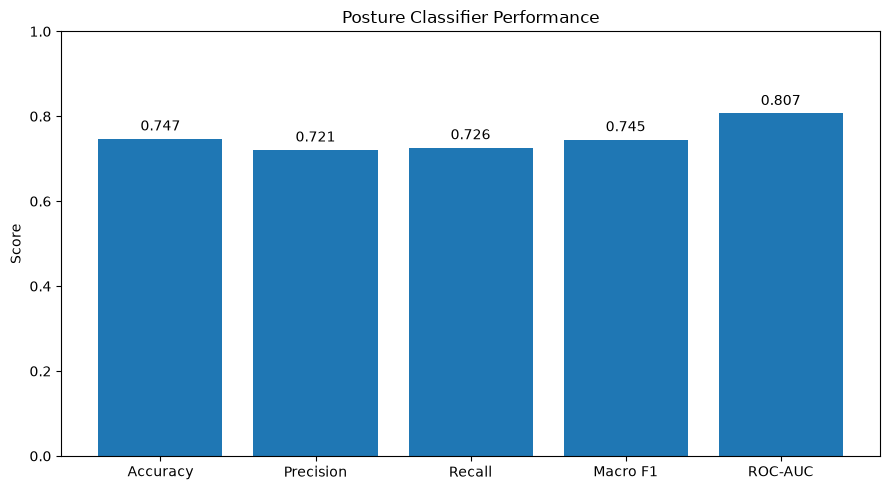

,Metric,Score
0,Accuracy,0.746622
1,Precision (GOOD),0.720588
2,Recall (GOOD),0.725926
3,Macro F1,0.744801
4,ROC-AUC,0.806579


In [12]:
metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "Macro F1",
    "ROC-AUC",
]

metric_values = [
    accuracy,
    precision,
    recall,
    macro_f1,
    roc_auc,
]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    metric_names,
    metric_values,
)

ax.set_ylim(0, 1)
ax.set_title("Posture Classifier Performance")
ax.set_ylabel("Score")

for bar, value in zip(bars, metric_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
    )

plt.tight_layout()

plt.savefig(
    os.path.join(RESULTS_DIR, "05_model_performance.png"),
    dpi=220,
    bbox_inches="tight",
)

plt.show()

metrics_df


## 10. Classification Report

In [13]:
report = classification_report(
    y_holdout,
    predictions,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(
    report
).transpose()

report_df


,precision,recall,f1-score,support
bad,0.768750,0.763975,0.766355,161.000000
good,0.720588,0.725926,0.723247,135.000000
accuracy,0.746622,0.746622,0.746622,0.746622
macro avg,0.744669,0.744951,0.744801,296.000000
weighted avg,0.746784,0.746622,0.746694,296.000000


## 11. Save Numerical Results

In [14]:
metrics_df.to_csv(
    os.path.join(RESULTS_DIR, "model_metrics.csv"),
    index=False,
)

report_df.to_csv(
    os.path.join(RESULTS_DIR, "classification_report.csv")
)

print("Submission results saved in:", RESULTS_DIR)


Submission results saved in: results


## Result Interpretation

The posture classifier is evaluated on an **unseen group-aware holdout set**. Related frames from the same source video are kept within the same group, reducing the risk of train/test leakage.

The final report should discuss:

- Overall classification accuracy
- Macro F1 score for balanced class evaluation
- ROC-AUC for discrimination performance
- GOOD-class precision and recall
- Confusion matrix behavior
- Dataset composition and source diversity

These results represent performance on the PresentAI Coach posture dataset and should not be interpreted as a universal posture benchmark.
